In [1]:
from pathlib import Path
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)


# file path from the marts folder 
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_MARTS = BASE_DIR / "data" / "marts"

FACT_YEARLY = DATA_MARTS / "fct_ip_flows_yearly.csv.gz"



# years
YEAR_START = 2013
YEAR_END   = 2023

# indicators for each row type in the final table
IP_ROWS = [
    ("Patents",               "Apps",   ["PA1a","PA1b"],             ["PA5"]),
    ("Patents",               "Grants", ["PA2a","PA2b"],             ["PA5"]),
    ("Trademarks",            "Apps",   ["TM1a","TM1b"],             ["TM4a","TM4b"]),
    ("Trademarks",            "Reg's",  ["TM2a","TM2b"],             ["TM4a","TM4b"]),
    ("Industrial Designs",    "App's",  ["ID1a","ID1b"],             ["ID4a","ID4b"]),
    ("Industrial Designs",    "Reg's",  ["ID2a","ID2b"],             ["ID4a","ID4b"]),
]

PA_APPS = ["PA1a", "PA1b"]
TM_APPS = ["TM1a", "TM1b"]
ID_APPS = ["ID1a", "ID1b"]

def sql_list(vals):
    """
    Turn ['Canada',"Japan"] into ('Canada','Japan') with proper escaping.
    If vals empty, return ('___NO_MATCH___') to avoid SQL errors.
    """
    if not vals:
        return "('___NO_MATCH___')"
    out = []
    for v in vals:
        v_esc = str(v).replace("'", "''")
        out.append("'" + v_esc + "'")
    return "(" + ",".join(out) + ")"


In [11]:
# Can handle A list of multiple countries in test_origins and test_dests - check Explore_IP_Fact_Tables.ipynb to see the exact name of Countries

test_origins = ["Canada"]

# test_dests   =  [
#     "African Regional Intellectual Property Organization",
#     "Botswana",
#     "Cabo Verde",
#     "Eswatini",
#     "Gambia",
#     "Ghana",
#     "Kenya",
#     "Lesotho",
#     "Liberia",
#     "Malawi",
#     "Mauritius",
#     "Mozambique",
#     "Namibia",
#     "Rwanda",
#     "Sao Tome and Principe",
#     "Seychelles",
#     "Sierra Leone",
#     "Sudan",
#     "Uganda",
#     "Zambia",
#     "Zimbabwe",
# ]

test_dests = ["Mexico"]


# test all the countries in the data
# test_All = [
#     "Afghanistan",
#     "African Intellectual Property Organization",
#     "African Regional Intellectual Property Organization",
#     "Albania",
#     "Algeria",
#     "Andorra",
#     "Angola",
#     "Antigua and Barbuda",
#     "Argentina",
#     "Armenia",
#     "Australia",
#     "Austria",
#     "Azerbaijan",
#     "Bahamas",
#     "Bahrain",
#     "Bangladesh",
#     "Barbados",
#     "Belarus",
#     "Belgium",
#     "Belize",
#     "Benelux Office for Intellectual Property",
#     "Benin",
#     "Bhutan",
#     "Bolivia (Plurinational State of)",
#     "Bonaire, Sint Eustatius and Saba",
#     "Bosnia and Herzegovina",
#     "Botswana",
#     "Brazil",
#     "Brunei Darussalam",
#     "Bulgaria",
#     "Burkina Faso",
#     "Burundi",
#     "Cabo Verde",
#     "Cambodia",
#     "Canada",
#     "Chile",
#     "China",
#     "China, Hong Kong SAR",
#     "China, Macao SAR",
#     "Colombia",
#     "Congo",
#     "Costa Rica",
#     "Croatia",
#     "Cuba",
#     "Curaçao",
#     "Cyprus",
#     "Czech Republic",
#     "Czechoslovakia",
#     "Côte d'Ivoire",
#     "Democratic People's Republic of Korea",
#     "Democratic Republic of the Congo",
#     "Denmark",
#     "Djibouti",
#     "Dominica",
#     "Dominican Republic",
#     "Ecuador",
#     "Egypt",
#     "El Salvador",
#     "Estonia",
#     "Eswatini",
#     "Ethiopia",
#     "Eurasian Patent Organization",
#     "European Patent Office",
#     "European Union Intellectual Property Office",
#     "Fiji",
#     "Finland",
#     "France",
#     "Gabon",
#     "Gambia",
#     "Georgia",
#     "German Democratic Republic",
#     "Germany",
#     "Ghana",
#     "Greece",
#     "Grenada",
#     "Guatemala",
#     "Guernsey",
#     "Guinea",
#     "Guinea-Bissau",
#     "Guyana",
#     "Haiti",
#     "Holy See",
#     "Honduras",
#     "Hungary",
#     "Iceland",
#     "India",
#     "Indonesia",
#     "Iran (Islamic Republic of)",
#     "Iraq",
#     "Ireland",
#     "Israel",
#     "Italy",
#     "Jamaica",
#     "Japan",
#     "Jordan",
#     "Kazakhstan",
#     "Kenya",
#     "Kiribati",
#     "Kuwait",
#     "Kyrgyzstan",
#     "Lao People's Democratic Republic",
#     "Latvia",
#     "Lebanon",
#     "Lesotho",
#     "Liberia",
#     "Libya",
#     "Liechtenstein",
#     "Lithuania",
#     "Luxembourg",
#     "Madagascar",
#     "Malawi",
#     "Malaysia",
#     "Maldives",
#     "Mali",
#     "Malta",
#     "Mauritius",
#     "Mexico",
#     "Monaco",
#     "Mongolia",
#     "Montenegro",
#     "Morocco",
#     "Mozambique",
#     "Myanmar",
#     "Namibia",
#     "Nepal",
#     "Netherlands (Kingdom of the)",
#     "Netherlands Antilles",
#     "New Zealand",
#     "Nicaragua",
#     "Niger",
#     "Nigeria",
#     "North Macedonia",
#     "Norway",
#     "Oman",
#     "Pakistan",
#     "Panama",
#     "Papua New Guinea",
#     "Paraguay",
#     "Patent Office of the Cooperation Council for the Arab States of the Gulf",
#     "Peru",
#     "Philippines",
#     "Poland",
#     "Portugal",
#     "Qatar",
#     "Republic of Korea",
#     "Republic of Moldova",
#     "Romania",
#     "Russian Federation",
#     "Rwanda",
#     "Saint Kitts and Nevis",
#     "Saint Lucia",
#     "Saint Vincent and the Grenadines",
#     "Samoa",
#     "San Marino",
#     "Sao Tome and Principe",
#     "Saudi Arabia",
#     "Senegal",
#     "Serbia",
#     "Seychelles",
#     "Sierra Leone",
#     "Singapore",
#     "Sint Maarten (Dutch Part)",
#     "Slovakia",
#     "Slovenia",
#     "Solomon Islands",
#     "Somalia",
#     "South Africa",
#     "Soviet Union",
#     "Spain",
#     "Sri Lanka",
#     "Sudan",
#     "Suriname",
#     "Sweden",
#     "Switzerland",
#     "Syrian Arab Republic",
#     "Tajikistan",
#     "Thailand",
#     "Tonga",
#     "Trinidad and Tobago",
#     "Tunisia",
#     "Turkmenistan",
#     "Tuvalu",
#     "Türkiye",
#     "Uganda",
#     "Ukraine",
#     "United Arab Emirates",
#     "United Kingdom",
#     "United Republic of Tanzania",
#     "United States of America",
#     "Uruguay",
#     "Uzbekistan",
#     "Vanuatu",
#     "Venezuela (Bolivarian Republic of)",
#     "Viet Nam",
#     "Yemen",
#     "Yugoslavia",
#     "Zaire",
#     "Zambia",
#     "Zimbabwe"
# ]


# TEST IP YEARS - Patent, Trademarks and Industrial Desgin

In [3]:
# Patent Applications and Grants
test_inds    = ["PA1a","PA1b"]  # Total Patent applications
# test_inds    = ["PA2a","PA2b"]  # Total Patent applications


# #Trademark Applications and Grants
# test_inds    = ["TM1a","TM1b"]  # Total Trademark applications
# test_inds    = ["TM2a","TM2b"]  # Total Trademark Grants

# #Industrial Desgin Applications and Grants
# test_inds    = ["TM1a","TM1b"]  # Total Industrial applications
# test_inds    = ["TM2a","TM2b"]  # Total Industrial Grants


In [8]:
PA_APPS = ["PA1a", "PA1b"]
TM_APPS = ["TM1a", "TM1b"]
ID_APPS = ["ID1a", "ID1b"]

### Get % change since X - Year


In [31]:
def get_bilateral_volume(origins, dests, years, indicators):
    """
    Return df with columns:
      year, indicator, volume
    where volume is SUM(count) for all (origins x dests x indicators).
    """
    o_list = sql_list(origins)
    d_list = sql_list(dests)
    i_list = sql_list(indicators)
    y_list = ",".join(str(y) for y in years)

    q = f"""
    SELECT
        year,
        indicator,
        SUM(count) AS volume
    FROM read_csv_auto('{FACT_YEARLY.as_posix()}')
    WHERE origin IN {o_list}
      AND destination_office IN {d_list}
      AND indicator IN {i_list}
      AND year IN ({y_list})
    GROUP BY 1,2
    ORDER BY year, indicator
    """
    return duckdb.sql(q).df()


In [ ]:
years_to_check = [YEAR_START, YEAR_END]

vol_df = get_bilateral_volume(
    origins=test_origins,
    dests=test_dests,
    years=years_to_check,
    indicators=TM_APPS  #Change the applications
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [34]:
print(vol_df)

   year indicator  volume
0  2013      PA1a     NaN
1  2013      PA1b     9.0
2  2023      PA1a     NaN
3  2023      PA1b    21.0


In [36]:
def get_total_for_year(vol_df, year):
    """
    Given the df from get_bilateral_volume,
    sum all indicators for a single year.
    """
    mask = (vol_df["year"] == year)
    if mask.any():
        return vol_df.loc[mask, "volume"].sum(skipna=True)
    return 0.0

def pct_change_2013_2023(vol_2013, vol_2023):
    """
    % change from YEAR_START to YEAR_END.
    If 2013 is zero, return NaN.
    """
    if vol_2013 == 0:
        return np.nan
    return ((vol_2023 - vol_2013) / vol_2013) * 100.0

In [37]:
vol_start = get_total_for_year(vol_df, YEAR_START)
vol_end   = get_total_for_year(vol_df, YEAR_END)
pct_chg   = pct_change_2013_2023(vol_start, vol_end)

In [38]:
print(f"Total {YEAR_START} volume:", vol_start)
print(f"Total {YEAR_END} volume:",   vol_end)
print(f"% change {YEAR_START}->{YEAR_END}: {pct_chg}")

Total 2013 volume: 9.0
Total 2023 volume: 21.0
% change 2013->2023: 133.33333333333331


### Get denominator and share of total

In [11]:
# Ex: we want what percent of X-Country total patent apps abroad went to Y-Country in YEAR_CURR?

In [39]:
def get_denominator_for_share(origins, year, indicators):
    """
    For a given origin(s)/year/indicator bundle, sum over ALL destination_office.
    This is the denominator for share.
    """
    o_list = sql_list(origins)
    i_list = sql_list(indicators)

    q = f"""
    SELECT
        SUM(count) AS vol_total
    FROM read_csv_auto('{FACT_YEARLY.as_posix()}')
    WHERE origin IN {o_list}
      AND indicator IN {i_list}
      AND year = {year}
    """
    result = duckdb.sql(q).fetchone()[0]
    return result or 0.0


In [40]:
denom_2023 = get_denominator_for_share(
    origins=test_origins,
    year=YEAR_END,
    indicators=PA_APPS
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [41]:
# total of CANADA->World for Patent Apps in 2023
print(denom_2023)

23936.0


In [42]:
def compute_share(origins, dests, year, indicators):
    """
    Share (%) = (origin -> dest volume in 'year')
                / (origin -> world volume in 'year')
                * 100
    """
    # numerator: just this bilateral (or group)
    bilateral_df = get_bilateral_volume(origins, dests, [year], indicators)
    bilateral_total = get_total_for_year(bilateral_df, year)

    # denominator: origin to world
    denom_total = get_denominator_for_share(origins, year, indicators)

    if denom_total == 0:
        return 0.0
    return (bilateral_total / denom_total) * 100.0

In [44]:
share_end = compute_share(
    origins=test_origins,
    dests=test_dests,
    year=YEAR_END,
    indicators=PA_APPS
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [45]:
print(f"Share in {YEAR_END} (% of {test_origins} total PA_APPS going to {test_dests}): {share_end:.2f}%")

Share in 2023 (% of ['Canada'] total PA_APPS going to ['African Regional Intellectual Property Organization', 'Botswana', 'Cabo Verde', 'Eswatini', 'Gambia', 'Ghana', 'Kenya', 'Lesotho', 'Liberia', 'Malawi', 'Mauritius', 'Mozambique', 'Namibia', 'Rwanda', 'Sao Tome and Principe', 'Seychelles', 'Sierra Leone', 'Sudan', 'Uganda', 'Zambia', 'Zimbabwe']): 0.09%


### Ranking Logic


In [5]:
def get_rank_for_dest_group(origins, dests, year, indicators):
    """
    Steps:
    1. For given origin(s), get volume to every destination_office for that year+indicators.
    2. Compute combined volume to *only* the chosen dests.
    3. Rank = 1 + how many single destinations beat that combined volume.
    Returns:
      rank_val, sel_vol, per_dest_df_sorted
    """
    o_list = sql_list(origins)
    i_list = sql_list(indicators)

    # volume per destination_office
    q_all = f"""
        SELECT
            destination_office,
            SUM(count) AS vol
        FROM read_csv_auto('{FACT_YEARLY.as_posix()}')
        WHERE origin IN {o_list}
          AND indicator IN {i_list}
          AND year = {year}
        GROUP BY 1
        ORDER BY vol DESC
    """
    per_dest = duckdb.sql(q_all).df()

    # combined volume for the chosen dests
    d_list = sql_list(dests)
    q_sel = f"""
        SELECT
            SUM(count) AS vol_sel
        FROM read_csv_auto('{FACT_YEARLY.as_posix()}')
        WHERE origin IN {o_list}
          AND indicator IN {i_list}
          AND year = {year}
          AND destination_office IN {d_list}
    """
    sel_vol = duckdb.sql(q_sel).fetchone()[0] or 0.0

    higher = (per_dest["vol"] > sel_vol).sum()
    rank_val = int(higher + 1)

    # sort table 
    per_dest_sorted = per_dest.sort_values("vol", ascending=False).reset_index(drop=True)

    return rank_val, sel_vol, per_dest_sorted


In [12]:
rank_2013, sel_2013, table_2013 = get_rank_for_dest_group(
    origins=test_origins,
    dests=test_dests,
    year=YEAR_END,
    indicators=PA_APPS
)
rank_2023, sel_2023, table_2023 = get_rank_for_dest_group(
    origins=test_origins,
    dests=test_dests,
    year=YEAR_START,
    indicators=PA_APPS
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [13]:
print(f" Rank test ({test_origins} -> {test_dests}) ")
print(f"{YEAR_START}: rank={rank_2013}, bilateral volume={sel_2013}")
print(table_2013.head(10))
print()
print(f"{YEAR_END}: rank={rank_2023}, bilateral volume={sel_2023}")
print(table_2023.head(10))

 Rank test (['Canada'] -> ['Mexico']) 
2013: rank=9, bilateral volume=292.0
         destination_office      vol
0  United States of America  11973.0
1                    Canada   4097.0
2    European Patent Office   2054.0
3                     China    949.0
4                     Japan    776.0
5                 Australia    635.0
6         Republic of Korea    486.0
7                     India    369.0
8                    Mexico    292.0
9      China, Hong Kong SAR    248.0

2023: rank=11, bilateral volume=262.0
         destination_office      vol
0  United States of America  12871.0
1                    Canada   4567.0
2    European Patent Office   1860.0
3                     China   1037.0
4                     Japan    691.0
5                 Australia    633.0
6                     India    468.0
7         Republic of Korea    410.0
8      China, Hong Kong SAR    337.0
9                    Brazil    315.0


## Build the year-by-year bilateral table (applications only)



In [52]:
def get_flow_timeseries(origins, dests, indicators,
                        year_start=YEAR_START, year_end=YEAR_END):
    """
    Return DataFrame with columns [year, volume]
    for each year in [year_start, year_end].
    Missing years become 0.
    """
    o_list = sql_list(origins)
    d_list = sql_list(dests)
    i_list = sql_list(indicators)

    q = f"""
    SELECT
        year,
        SUM(count) AS volume
    FROM read_csv_auto('{FACT_YEARLY.as_posix()}')
    WHERE origin IN {o_list}
      AND destination_office IN {d_list}
      AND indicator IN {i_list}
      AND year BETWEEN {year_start} AND {year_end}
    GROUP BY year
    ORDER BY year
    """
    df = duckdb.sql(q).df()

    # ensure all years appear
    all_years = pd.DataFrame({"year": list(range(year_start, year_end + 1))})
    df = all_years.merge(df, on="year", how="left")
    df["volume"] = df["volume"].fillna(0)
    return df

In [53]:
def build_bilateral_yearly_table(
    origins_sideA,
    dests_sideB,
    label_sideA="CAN",
    label_sideB="AF",
    year_start=YEAR_START,
    year_end=YEAR_END
):
    """
    Create final time series table.
    Uses *applications* indicators (PA_APPS/TM_APPS/ID_APPS) in both directions.
    """


    # flows A -> B
    pa_AtoB = get_flow_timeseries(test_origins, test_dests, PA_APPS, year_start, year_end)
    tm_AtoB = get_flow_timeseries(test_origins, test_dests, TM_APPS, year_start, year_end)
    id_AtoB = get_flow_timeseries(test_origins, test_dests, ID_APPS, year_start, year_end)

    # flows B -> A
    pa_BtoA = get_flow_timeseries( test_dests,test_origins, PA_APPS, year_start, year_end)
    tm_BtoA = get_flow_timeseries(test_dests,test_origins, TM_APPS, year_start, year_end)
    id_BtoA = get_flow_timeseries(test_dests,test_origins, ID_APPS, year_start, year_end)

    # merge into one frame
    out = (
        pa_AtoB.rename(columns={"volume": f"PA From {label_sideA} to {label_sideB}"})
        .merge(
            tm_AtoB.rename(columns={"volume": f"TM From {label_sideA} to {label_sideB}"}),
            on="year", how="left"
        )
        .merge(
            id_AtoB.rename(columns={"volume": f"ID From {label_sideA} to {label_sideB}"}),
            on="year", how="left"
        )
        .merge(
            id_BtoA.rename(columns={"volume": f"ID From {label_sideB} to {label_sideA}"}),
            on="year", how="left"
        )
        .merge(
            pa_BtoA.rename(columns={"volume": f"PA From {label_sideB} to {label_sideA}"}),
            on="year", how="left"
        )
        .merge(
            tm_BtoA.rename(columns={"volume": f"TM From {label_sideB} to {label_sideA}"}),
            on="year", how="left"
        )
    )

    # make volumes look nice (ints)
    for c in out.columns:
        if c != "year":
            out[c] = out[c].round(0).astype(int)

    return out[[
        "year",
        f"PA From {label_sideA} to {label_sideB}",
        f"TM From {label_sideA} to {label_sideB}",
        f"ID From {label_sideA} to {label_sideB}",
        f"ID From {label_sideB} to {label_sideA}",
        f"PA From {label_sideB} to {label_sideA}",
        f"TM From {label_sideB} to {label_sideA}",
    ]]

In [54]:
final_table = build_bilateral_yearly_table(
    origins_sideA=test_origins,
    dests_sideB=test_dests,
    label_sideA="CAN",
    label_sideB="ARIPO",
    year_start=YEAR_START,
    year_end=YEAR_END
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [56]:
display(final_table)

,year,PA From CAN to ARIPO,TM From CAN to ARIPO,ID From CAN to ARIPO,ID From ARIPO to CAN,PA From ARIPO to CAN,TM From ARIPO to CAN
0,2013,9,12,0,0,9,17
1,2014,11,17,5,1,5,15
2,2015,16,24,0,1,4,13
3,2016,12,27,1,2,5,23
4,2017,14,15,0,2,6,21
5,2018,9,58,0,0,6,29
6,2019,8,43,10,1,2,18
7,2020,11,428,2,0,6,34
8,2021,13,81,0,0,6,34
9,2022,13,48,13,35,7,13


In [57]:
# make a line chart
time_col = "year"
flow_cols = [
    col for col in final_table.columns
    if col != time_col
]

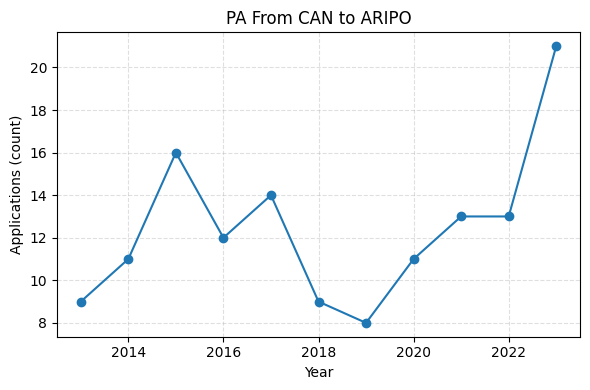

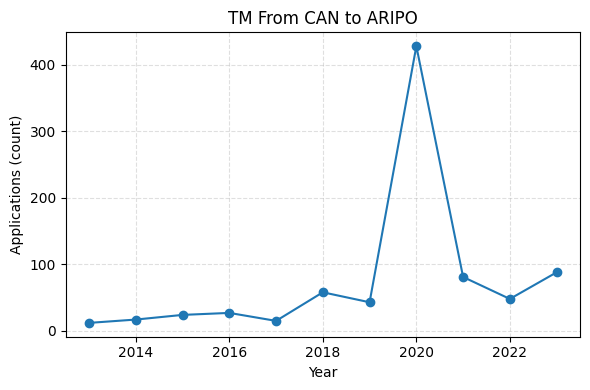

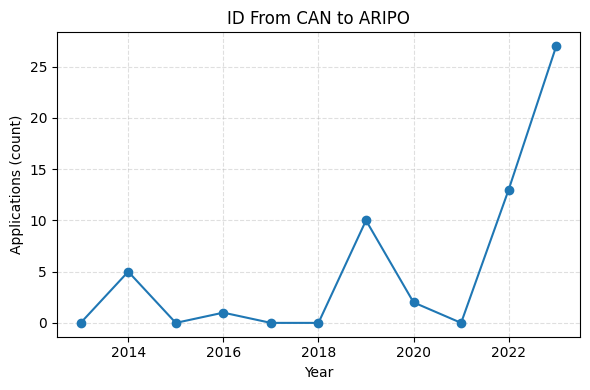

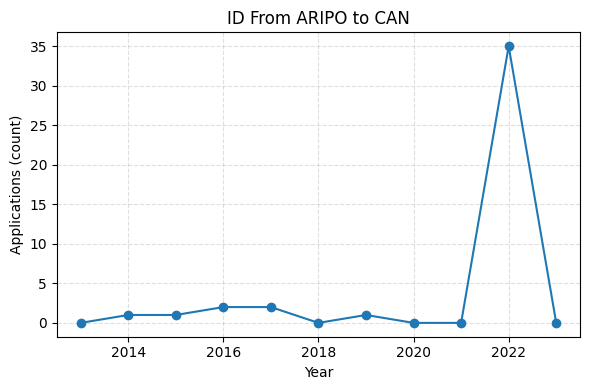

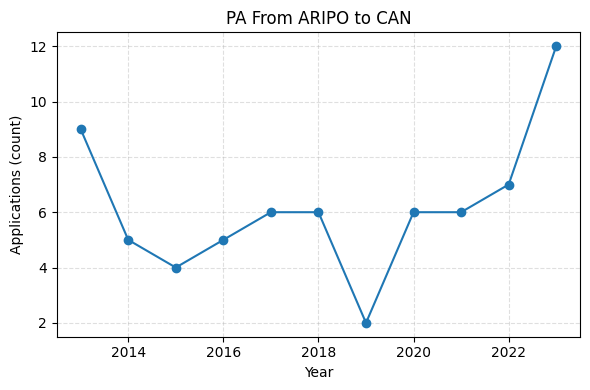

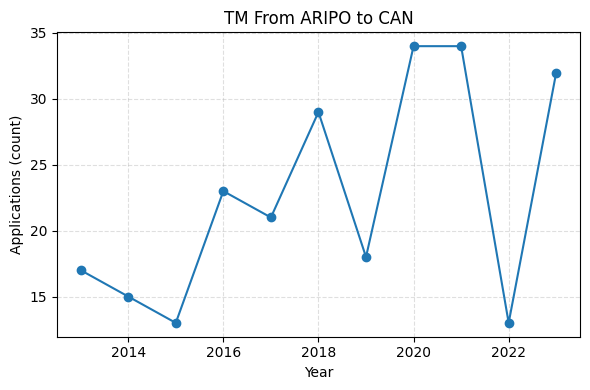

In [59]:
for col in flow_cols:
    plt.figure(figsize=(6,4))
    plt.plot(final_table[time_col], final_table[col], marker="o")
    plt.title(col)
    plt.xlabel("Year")
    plt.ylabel("Applications (count)")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

## Percentage of global filings abroad by origins


In [108]:
test_origins   =  [
"Japan"
]

In [109]:
def _origin_total_by_year(origins, indicators, year_start, year_end):
    """
    Numerator:
    For each year, sum of counts where:
      - origin in <origins>
      - indicator in <indicators>
    NO restriction on destination_office.
    Returns df: year, vol_origin_total
    """
    o_list = sql_list(origins)
    i_list = sql_list(indicators)

    q = f"""
    SELECT
        year,
        SUM(count) AS vol_origin_total
    FROM read_csv_auto('{FACT_YEARLY.as_posix()}')
    WHERE origin IN {o_list}
      AND indicator IN {i_list}
      AND year BETWEEN {year_start} AND {year_end}
    GROUP BY year
    ORDER BY year
    """
    return duckdb.sql(q).df()

def _world_total_by_year(indicators, year_start, year_end):
    """
    Denominator:
    For each year, sum of counts where:
      - indicator in <indicators>
    NO restriction on origin or destination_office.
    Returns df: year, vol_world_total
    """
    i_list = sql_list(indicators)

    q = f"""
    SELECT
        year,
        SUM(count) AS vol_world_total
    FROM read_csv_auto('{FACT_YEARLY.as_posix()}')
    WHERE indicator IN {i_list}
      AND year BETWEEN {year_start} AND {year_end}
    GROUP BY year
    ORDER BY year
    """
    return duckdb.sql(q).df()

In [110]:
#origin total by year
origin_tot_pa = _origin_total_by_year(
    origins=test_origins,
    indicators=PA_APPS,          
    year_start=YEAR_START,
    year_end=YEAR_END
)
display(origin_tot_pa)


,year,vol_origin_total
0,2013,464891.0
1,2014,458486.0
2,2015,450923.0
3,2016,448578.0
4,2017,452623.0
5,2018,452788.0
6,2019,446783.0
7,2020,418195.0
8,2021,409075.0
9,2022,403471.0


In [111]:
#world total by year
world_tot_pa = _world_total_by_year(
    indicators=PA_APPS,
    year_start=YEAR_START,
    year_end=YEAR_END
)
display(world_tot_pa)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,year,vol_world_total
0,2013,2521315.0
1,2014,2632129.0
2,2015,2812440.0
3,2016,3069057.0
4,2017,3119687.0
5,2018,3287754.0
6,2019,3184320.0
7,2020,3241565.0
8,2021,3352217.0
9,2022,3417212.0


In [113]:
def pct_global_total_from_origin_table(origins, year_start, year_end):
    """
    For each year:
        pct_global_*_from_origin_total
        = (all filings from origin(s), including domestic)
          / (all global filings)
          * 100
    for Patents, Trademarks, Industrial Designs (applications only).
    """

    # Patents
    pa_num = _origin_total_by_year(
        origins=origins,
        indicators=PA_APPS,
        year_start=year_start,
        year_end=year_end,
    )
    pa_den = _world_total_by_year(
        indicators=PA_APPS,
        year_start=year_start,
        year_end=year_end,
    )
    pa = pd.merge(pa_num, pa_den, on="year", how="outer")
    pa["pct_global_PA_from_origin_total"] = (
        pa["vol_origin_total"] / pa["vol_world_total"] * 100.0
    )

    # Trademarks
    tm_num = _origin_total_by_year(
        origins=origins,
        indicators=TM_APPS,
        year_start=year_start,
        year_end=year_end,
    )
    tm_den = _world_total_by_year(
        indicators=TM_APPS,
        year_start=year_start,
        year_end=year_end,
    )
    tm = pd.merge(tm_num, tm_den, on="year", how="outer")
    tm["pct_global_TM_from_origin_total"] = (
        tm["vol_origin_total"] / tm["vol_world_total"] * 100.0
    )

    # Industrial Designs
    id_num = _origin_total_by_year(
        origins=origins,
        indicators=ID_APPS,
        year_start=year_start,
        year_end=year_end,
    )
    id_den = _world_total_by_year(
        indicators=ID_APPS,
        year_start=year_start,
        year_end=year_end,
    )
    idf = pd.merge(id_num, id_den, on="year", how="outer")
    idf["pct_global_ID_from_origin_total"] = (
        idf["vol_origin_total"] / idf["vol_world_total"] * 100.0
    )

    # stitch final
    out = (
        pd.DataFrame({"year": range(year_start, year_end + 1)})
        .merge(pa[["year", "pct_global_PA_from_origin_total"]], on="year", how="left")
        .merge(tm[["year", "pct_global_TM_from_origin_total"]], on="year", how="left")
        .merge(idf[["year", "pct_global_ID_from_origin_total"]], on="year", how="left")
    )

    # replace NaN with 0 just in case
    value_cols = [c for c in out.columns if c != "year"]
    out[value_cols] = out[value_cols].fillna(0)

    return out


In [114]:
global_share_tbl = pct_global_total_from_origin_table(
    origins=test_origins,        
    year_start=YEAR_START,       
    year_end=YEAR_END            
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [115]:
print(f"Percentage of global filings abroad by {test_origins}")
display(global_share_tbl)

Percentage of global filings abroad by ['Japan']


,year,pct_global_PA_from_origin_total,pct_global_TM_from_origin_total,pct_global_ID_from_origin_total
0,2013,18.438434,3.145943,4.249708
1,2014,17.418827,2.310848,4.495941
2,2015,16.033160,2.951926,4.446894
3,2016,14.616151,2.706086,3.992789
4,2017,14.508603,5.547871,4.059632
5,2018,13.771955,5.080533,3.623093
6,2019,14.030719,4.972396,3.470511
7,2020,12.901022,4.068706,3.092400
8,2021,12.203118,3.589912,2.816407
9,2022,11.807023,3.650502,2.814244


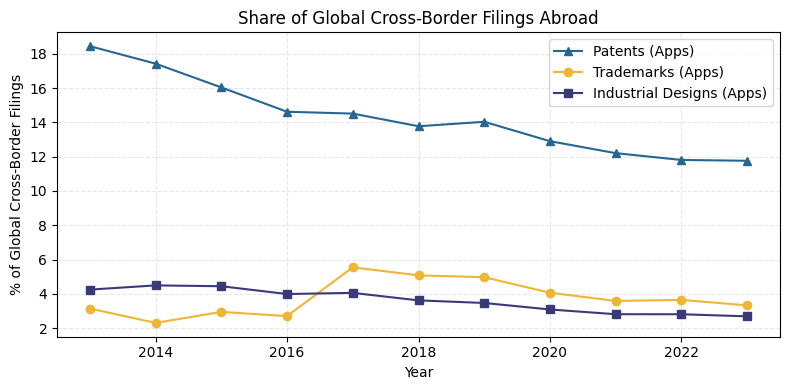

In [116]:


fig, ax = plt.subplots(figsize=(8,4))

# Patents
ax.plot(
    global_share_tbl["year"],
    global_share_tbl["pct_global_PA_from_origin_total"],
    marker="^",
    linestyle="-",
    color="#276691",
    label="Patents (Apps)"
)

# Trademarks
ax.plot(
    global_share_tbl["year"],
    global_share_tbl["pct_global_TM_from_origin_total"],
    marker="o",
    linestyle="-",
    color="#EFB537",
    label="Trademarks (Apps)"
)

# Industrial Designs
ax.plot(
    global_share_tbl["year"],
    global_share_tbl["pct_global_ID_from_origin_total"],
    marker="s",
    linestyle="-",
    color="#3B3A78",
    label="Industrial Designs (Apps)"
)

ax.set_xlabel("Year")
ax.set_ylabel("% of Global Cross-Border Filings")
ax.set_title("Share of Global Cross-Border Filings Abroad")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


# CLASS TEST - Tech, Locarno and Nice

### Top Industries

In [128]:
#industry_inds = ["TM4a", "TM4b"]        # Nice class (trademark)
industry_inds = ["PA5"]                  # tech class (Patent)
#industry_inds = ["ID4a", "ID4b"]        # Locarno Class (Trademarks)

In [136]:
test_origins   =  [
    "African Regional Intellectual Property Organization",
    "Botswana",
    "Cabo Verde",
    "Eswatini",
    "Gambia",
    "Ghana",
    "Kenya",
    "Lesotho",
    "Liberia",
    "Malawi",
    "Mauritius",
    "Mozambique",
    "Namibia",
    "Rwanda",
    "Sao Tome and Principe",
    "Seychelles",
    "Sierra Leone",
    "Sudan",
    "Uganda",
    "Zambia",
    "Zimbabwe",
]

In [129]:
def get_top_two_industries_with_pct(origins, dests, year, industry_indicators, top_n=10):
    """
    Same idea as before, but now also compute % share for each class_code.

    % share = vol(class_code) / total_vol_all_classes_for_that_flow * 100
    """

    o_list = sql_list(origins)
    d_list = sql_list(dests)
    i_list = sql_list(industry_indicators)

    # full breakdown by class_code for this flow
    q_full = f"""
    SELECT
        class_code,
        SUM(count) AS vol
    FROM read_csv_auto('{FACT_CLASS.as_posix()}')
    WHERE origin IN {o_list}
      AND destination_office IN {d_list}
      AND ip_indicator IN {i_list}
      AND year = {year}
    GROUP BY class_code
    ORDER BY vol DESC
    """
    full_df = duckdb.sql(q_full).df()

    if full_df.empty:
        return full_df  # nothing to do

    # total volume across ALL classes for denominator
    total_vol = full_df["vol"].sum()

    # take the top_n rows
    top_df = full_df.nlargest(top_n, "vol").copy()

    # add % column
    top_df["pct_share"] = (top_df["vol"] / total_vol * 100.0).round(2)

    # make sure class_code is string so it prints nicely
    top_df["class_code"] = top_df["class_code"].astype(str)

    return top_df.reset_index(drop=True)

In [137]:
top_industries_df = get_top_two_industries_with_pct(
    origins=test_origins,
    dests=test_All,
    year=YEAR_END,
    industry_indicators=industry_inds,
    top_n=10
)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [138]:
display(top_industries_df)

,class_code,vol,pct_share
0,13 - Medical technology,8.0,10.81
1,19 - Basic materials chemistry,8.0,10.81
2,16 - Pharmaceuticals,7.0,9.46
3,29 - Other special machines,6.0,8.11
4,4 - Digital communication,5.0,6.76
5,32 - Transport,4.0,5.41
6,25 - Handling,4.0,5.41
7,"20 - Materials, metallurgy",3.0,4.05
8,7 - IT methods for management,3.0,4.05
9,"27 - Engines, pumps, turbines",3.0,4.05
